# Stopień i siła węzła w sieci rowerowej

Notebook liczy rozkłady `P(k_in)` i `P(k_out)` oraz ważone odpowiedniki `P(s_in)` i `P(s_out)` dla skierowanej sieci przejazdów rowerowych. Jako wejście bierzemy już wyczyszczone dane bez nieciągłości stacji: `rides_data_without_discontinuities.parquet`. Obliczenia wykonujemy tylko dla przejazdów o czasie trwania od 3 do 180 minut.

Węzłem jest stacja, a krawędź `i -> j` oznacza, że po czyszczeniu istnieje co najmniej jeden przejazd ze stacji `i` do stacji `j`. Pętle `i -> i` pomijamy, bo nie dodają nowego sąsiedztwa.


In [28]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [29]:
def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for path in [current, *current.parents]:
        if (path / "Data").exists():
            return path
    raise FileNotFoundError("Nie znaleziono katalogu projektu z folderem Data/.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "Data"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import plot_style
plot_style.apply_montserrat_style()

MIN_DURATION_MINUTES = 3
MAX_DURATION_MINUTES = 180

RIDES_FILE = DATA_DIR / "rides_data_without_discontinuities.parquet"
STATIONS_FILE = DATA_DIR / "stations_df.parquet"

if not RIDES_FILE.exists():
    raise FileNotFoundError(f"Brakuje wyczyszczonych danych bez nieciągłości: {RIDES_FILE}")
if not STATIONS_FILE.exists():
    raise FileNotFoundError(f"Brakuje pliku ze stacjami: {STATIONS_FILE}")

RIDES_FILE, STATIONS_FILE


(PosixPath('/Users/artur/Studia/Rowerki/Data/rides_data_without_discontinuities.parquet'),
 PosixPath('/Users/artur/Studia/Rowerki/Data/stations_df.parquet'))

## Budowa skierowanej sieci

Z danych przejazdów bierzemy tylko pary `(start_station_id, end_station_id)`. Wystarczy informacja, czy krawędź istnieje, więc po usunięciu pętli zostawiamy unikalne pary stacji.


In [30]:
use_columns = ["start_station_id", "end_station_id", "total_duration_minutes"]

rides_raw = pd.read_parquet(RIDES_FILE, columns=use_columns)
stations = pd.read_parquet(STATIONS_FILE, columns=["station_id", "station_name"])

duration_mask = rides_raw["total_duration_minutes"].between(
    MIN_DURATION_MINUTES,
    MAX_DURATION_MINUTES,
    inclusive="both",
)
rides = rides_raw.loc[duration_mask].copy()

rides = rides.dropna(subset=["start_station_id", "end_station_id"]).copy()
rides["start_station_id"] = rides["start_station_id"].astype("int64")
rides["end_station_id"] = rides["end_station_id"].astype("int64")

stations = stations.dropna(subset=["station_id"]).copy()
stations["station_id"] = stations["station_id"].astype("int64")

edge_pairs = rides.loc[
    rides["start_station_id"] != rides["end_station_id"],
    ["start_station_id", "end_station_id"],
].drop_duplicates()

station_ids = sorted(
    set(stations["station_id"])
    | set(edge_pairs["start_station_id"])
    | set(edge_pairs["end_station_id"])
)

N = len(station_ids)

print("Źródło danych:", RIDES_FILE.name)
print("Zakres czasu trwania:", f"{MIN_DURATION_MINUTES}-{MAX_DURATION_MINUTES} min")
print("Liczba przejazdów przed filtrem czasu:", f"{len(rides_raw):,}".replace(",", " "))
print("Liczba przejazdów po filtrze czasu:", f"{len(rides):,}".replace(",", " "))
print("Liczba stacji N:", N)
print("Liczba skierowanych krawędzi bez pętli:", len(edge_pairs))


Źródło danych: rides_data_without_discontinuities.parquet
Zakres czasu trwania: 3-180 min
Liczba przejazdów przed filtrem czasu: 16 091 818
Liczba przejazdów po filtrze czasu: 15 377 692
Liczba stacji N: 801
Liczba skierowanych krawędzi bez pętli: 491788


## Stopień wejściowy i wyjściowy

Dla skierowanej macierzy sąsiedztwa `A`:

\[
k_i^{out} = \sum_j A_{ij}
\]

\[
k_i^{in} = \sum_j A_{ji}
\]


In [31]:
station_to_index = {station_id: index for index, station_id in enumerate(station_ids)}

adjacency_matrix = np.zeros((N, N), dtype=np.uint8)
start_indices = edge_pairs["start_station_id"].map(station_to_index).to_numpy()
end_indices = edge_pairs["end_station_id"].map(station_to_index).to_numpy()
adjacency_matrix[start_indices, end_indices] = 1

k_out = adjacency_matrix.sum(axis=1).astype("int64")
k_in = adjacency_matrix.sum(axis=0).astype("int64")

station_names = stations[["station_id", "station_name"]].drop_duplicates("station_id")

degree_df = pd.DataFrame({
    "station_id": station_ids,
    "k_out": k_out,
    "k_in": k_in,
}).merge(station_names, on="station_id", how="left")

degree_df = degree_df.sort_values(["k_in", "k_out"], ascending=False).reset_index(drop=True)

print("Średni k_out:", f"{k_out.mean():.2f}")
print("Średni k_in:", f"{k_in.mean():.2f}")
print("Maksymalny k_out:", int(k_out.max()))
print("Maksymalny k_in:", int(k_in.max()))

degree_df.head(10)


Średni k_out: 613.97
Średni k_in: 613.97
Maksymalny k_out: 794
Maksymalny k_in: 793


,station_id,k_out,k_in,station_name
0,1052,791,793,"Soho Square , Soho"
1,1160,794,791,"Craven Street, Strand"
2,1151,792,790,"Whitehall Place, Strand"
3,200128,783,790,"Queen Street 2, Bank"
4,995,793,789,"Little Argyll Street, West End"
5,300249,794,788,"Westminster Pier, Westminster"
6,1067,779,788,"St. James's Square, St. James's"
7,200202,778,787,"Storey's Gate, Westminster"
8,960,787,784,"Hop Exchange, The Borough"
9,2696,780,783,"Waterloo Station 1, Waterloo"


## Binowanie logarytmiczne

Do wykresów `P(k_in)` i `P(k_out)` używamy binowania logarytmicznego tak jak w notebooku pomocniczym. Granice przedziałów rosną przez mnożenie przez parametr `a`, punkt na osi X jest środkiem geometrycznym binu, a wartość na osi Y normalizujemy przez liczbę stacji i szerokość binu:

\[
P_{bin}(k) = \frac{N_{bin}}{N \cdot \Delta k}
\]


In [32]:
LOG_BIN_FACTORS = [1.05, 1.10, 1.25]


def log_binning(data, a):
    if a <= 1:
        raise ValueError("Parametr a musi być większy od 1.")

    data = np.asarray(data, dtype=float)
    data = data[data > 0]
    if len(data) == 0:
        raise ValueError("Brak dodatnich wartości do binowania.")

    bin_edges = [data.min()]
    while bin_edges[-1] <= data.max():
        bin_edges.append(bin_edges[-1] * a)
    bin_edges = np.array(bin_edges)

    counts, edges = np.histogram(data, bins=bin_edges)
    widths = edges[1:] - edges[:-1]
    probability_density = counts / (len(data) * widths)
    k = np.sqrt(edges[:-1] * edges[1:])

    mask = counts > 0
    return pd.DataFrame({
        "k": k[mask],
        "liczba_stacji_w_binie": counts[mask],
        "szerokosc_binu": widths[mask],
        "P_k_binned": probability_density[mask],
    })


log_binned_degree = {
    "k_in": {a: log_binning(k_in, a) for a in LOG_BIN_FACTORS},
    "k_out": {a: log_binning(k_out, a) for a in LOG_BIN_FACTORS},
}

log_binned_degree["k_in"][LOG_BIN_FACTORS[0]].head(10)


,k,liczba_stacji_w_binie,szerokosc_binu,P_k_binned
0,13.321036,1,0.650000,0.001921
1,214.945347,1,10.488259,0.000119
2,236.977245,1,11.563306,0.000108
3,261.267413,1,12.748544,0.000098
4,274.330784,3,13.385972,0.000280
5,288.047323,2,14.055270,0.000178
6,302.449689,1,14.758034,0.000085
7,317.572173,5,15.495935,0.000403
8,333.450782,3,16.270732,0.000230
9,350.123321,4,17.084269,0.000292


## Wykres porównawczy `P(k_in)` i `P(k_out)`

Na końcu porównujemy rozkład stopnia wejściowego i wyjściowego na jednym wykresie. Używamy binowania logarytmicznego tylko dla `a = 1.1`.


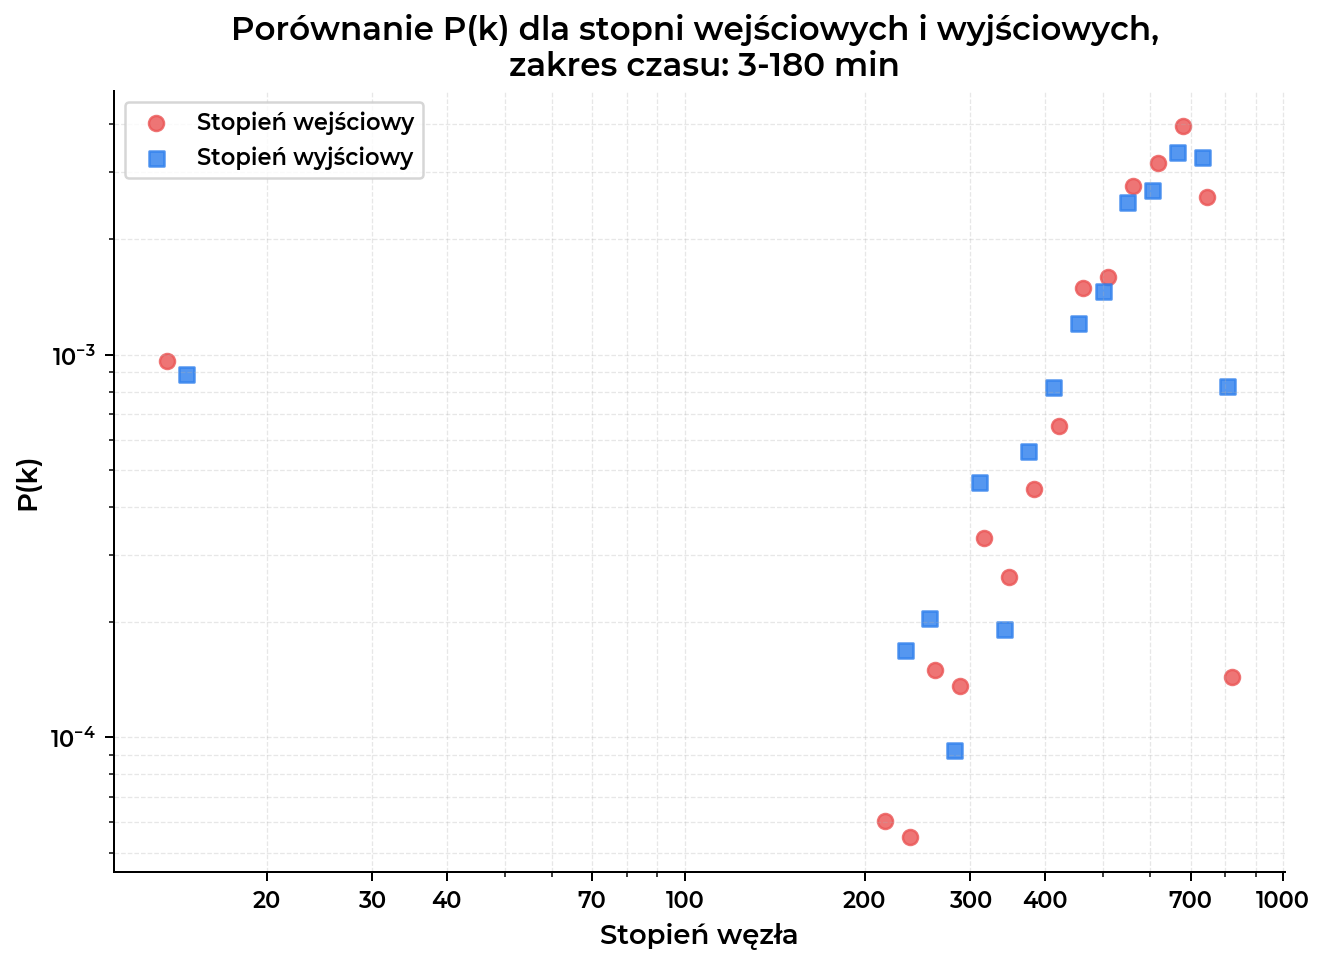

In [33]:
selected_a = 1.1

fig, ax = plt.subplots(figsize=(7.5, 5.5))

plot_specs = [
    ("k_in", "Stopień wejściowy", "#EB5757", "o"),
    ("k_out", "Stopień wyjściowy", "#2F80ED", "s"),
]

for degree_name, label, color, marker in plot_specs:
    result = log_binned_degree[degree_name][selected_a]
    ax.scatter(
        result["k"],
        result["P_k_binned"],
        s=36,
        alpha=0.82,
        color=color,
        marker=marker,
        label=label,
    )

ax.set_xscale("log")
from matplotlib.ticker import LogLocator, ScalarFormatter

ax.xaxis.set_major_locator(
    LogLocator(base=10, subs=(1, 2, 3, 4, 7,), numticks=20)
)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_yscale("log")
ax.set_xlabel("Stopień węzła")
ax.set_ylabel("P(k)")
ax.set_title(f"Porównanie P(k) dla stopni wejściowych i wyjściowych, \n zakres czasu: {MIN_DURATION_MINUTES}-{MAX_DURATION_MINUTES} min")
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()


## Siła wejściowa i wyjściowa

Teraz liczymy ważony odpowiednik stopnia. Nie pytamy już tylko, z iloma różnymi stacjami dana stacja jest połączona, ale ile przejazdów przez nią przechodzi.

\[
w_{ij} = \text{liczba przejazdów ze stacji } i \text{ do stacji } j
\]

\[
s_i^{out} = \sum_j w_{ij}
\]

\[
s_i^{in} = \sum_j w_{ji}
\]

`s_i^{out}` to liczba przejazdów rozpoczynających się na stacji `i`, a `s_i^{in}` to liczba przejazdów kończących się na tej stacji. W tej części wliczamy też przejazdy `i -> i`, bo nadal zwiększają liczbę startów i końców danej stacji.


In [34]:
weighted_edges = (
    rides
    .groupby(["start_station_id", "end_station_id"], observed=True)
    .size()
    .rename("w_ij")
    .reset_index()
)

station_index = pd.Index(station_ids, name="station_id")

s_out = (
    weighted_edges
    .groupby("start_station_id")["w_ij"]
    .sum()
    .reindex(station_index, fill_value=0)
    .astype("int64")
    .to_numpy()
)

s_in = (
    weighted_edges
    .groupby("end_station_id")["w_ij"]
    .sum()
    .reindex(station_index, fill_value=0)
    .astype("int64")
    .to_numpy()
)

strength_df = pd.DataFrame({
    "station_id": station_ids,
    "s_out": s_out,
    "s_in": s_in,
}).merge(station_names, on="station_id", how="left")

strength_df = strength_df.sort_values(["s_in", "s_out"], ascending=False).reset_index(drop=True)

print("Suma s_out:", int(s_out.sum()))
print("Suma s_in:", int(s_in.sum()))
print("Liczba przejazdów w danych:", len(rides))
print("Maksymalne s_out:", int(s_out.max()))
print("Maksymalne s_in:", int(s_in.max()))

strength_df.head(10)


Suma s_out: 15377692
Suma s_in: 15377692
Liczba przejazdów w danych: 15377692
Maksymalne s_out: 108575
Maksymalne s_in: 101263


,station_id,s_out,s_in,station_name
0,1075,108575,101263,"Hyde Park Corner, Hyde Park"
1,1072,81928,93688,"Waterloo Station 3, Waterloo"
2,960,66335,78296,"Hop Exchange, The Borough"
3,2696,47525,78202,"Waterloo Station 1, Waterloo"
4,1161,62206,73082,"Brushfield Street, Liverpool Street"
5,2587,75948,70954,"Wormwood Street, Liverpool Street"
6,1067,51640,69652,"St. James's Square, St. James's"
7,1132,72689,68989,"Albert Gate, Hyde Park"
8,22179,57071,66671,"Exhibition Road, Knightsbridge"
9,300083,65344,65064,"Duke Street Hill, London Bridge"


## Wykres porównawczy `P(s_in)` i `P(s_out)`

Rozkłady siły węzła rysujemy tak samo jak wcześniej rozkłady stopnia: z binowaniem logarytmicznym i parametrem `a = 1.1`.


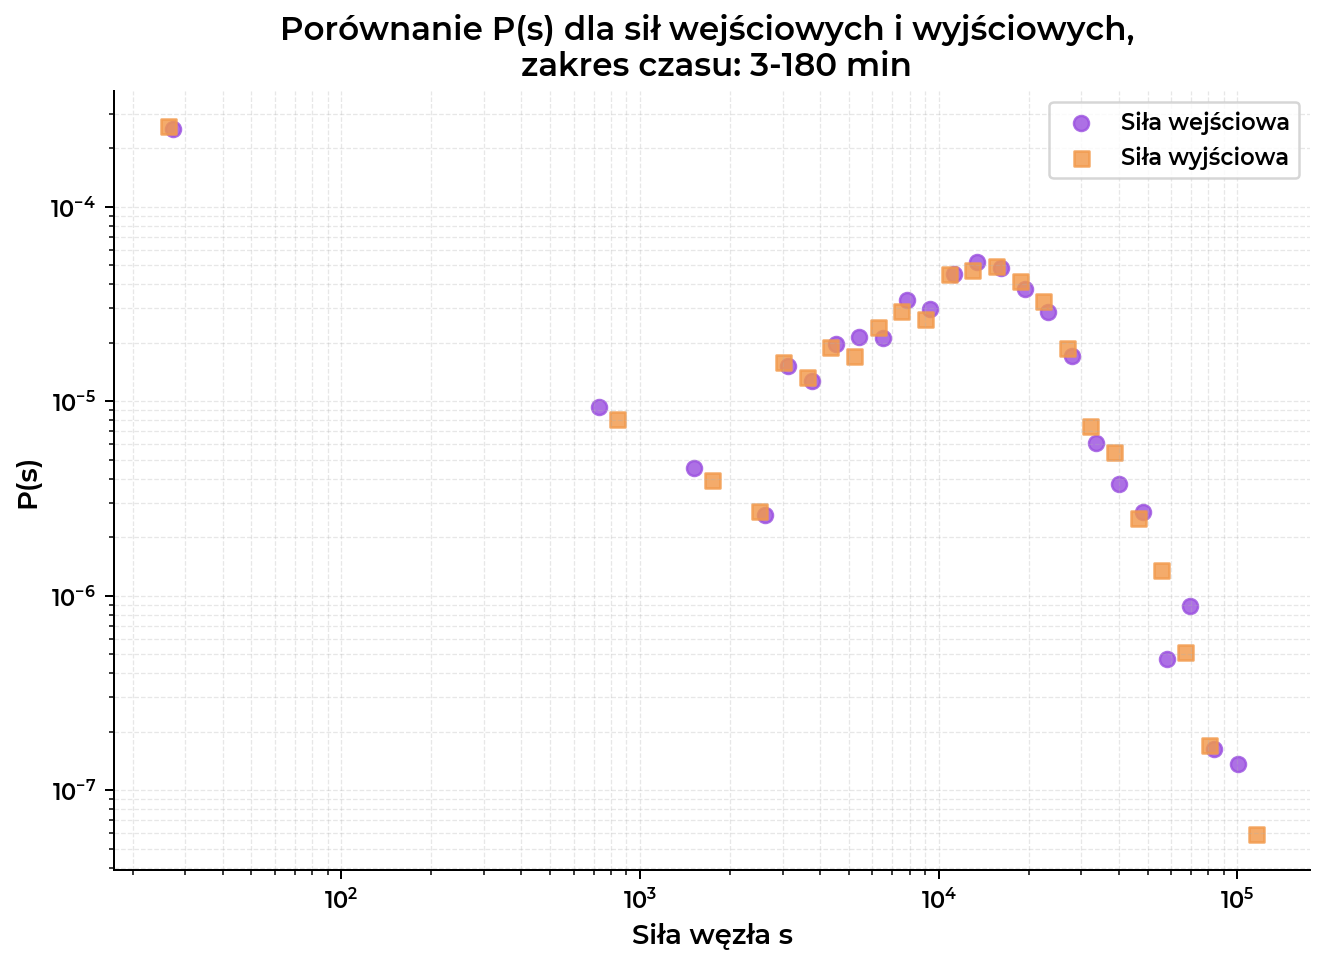

In [35]:
strength_a = 1.2

log_binned_strength = {
    "s_in": log_binning(s_in, strength_a),
    "s_out": log_binning(s_out, strength_a),
}

fig, ax = plt.subplots(figsize=(7.5, 5.5))

strength_plot_specs = [
    ("s_in", "Siła wejściowa", "#9B51E0", "o"),
    ("s_out", "Siła wyjściowa", "#F2994A", "s"),
]

for strength_name, label, color, marker in strength_plot_specs:
    result = log_binned_strength[strength_name]
    ax.scatter(
        result["k"],
        result["P_k_binned"],
        s=36,
        alpha=0.82,
        color=color,
        marker=marker,
        label=label,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Siła węzła s")
ax.set_ylabel("P(s)")
ax.set_title(f"Porównanie P(s) dla sił wejściowych i wyjściowych, \n zakres czasu: {MIN_DURATION_MINUTES}-{MAX_DURATION_MINUTES} min")
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()


Dopasowanie ogona rozkładu siły węzłów:
Początek dopasowania: 20000
Zakres binów: 22361.862-115382.298
Liczba punktów dopasowania: 18
Nachylenie = -3.868
Wyraz wolny = 12.383


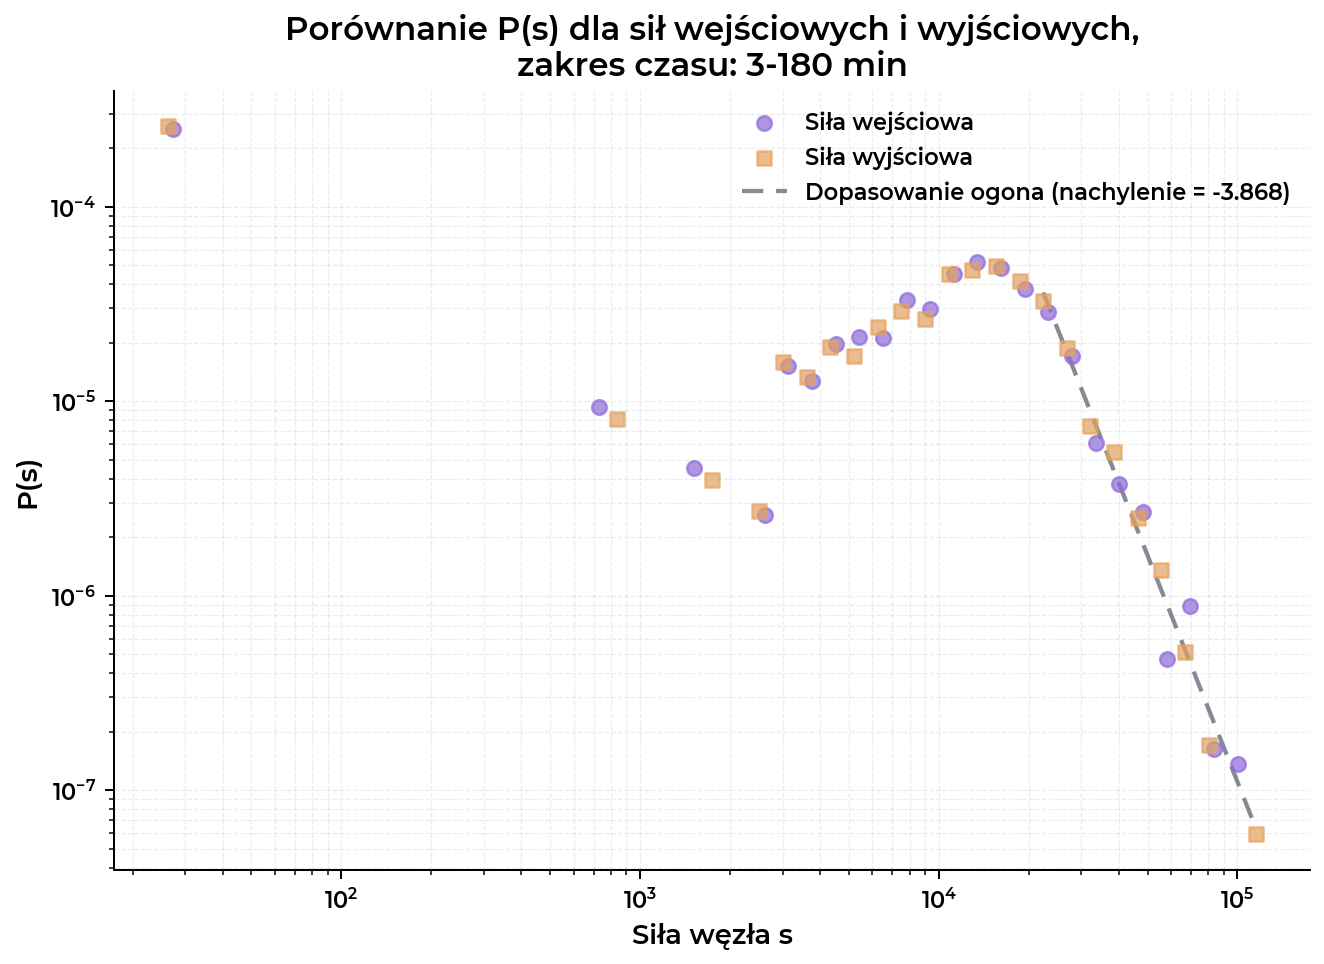

In [41]:
# ---------- Dopasowanie prostej do ogona rozkładu siły węzłów ----------

strength_a = 1.2
strength_fit_min = 2_0000

log_binned_strength = {
    "s_in": log_binning(s_in, strength_a),
    "s_out": log_binning(s_out, strength_a),
}

fig, ax = plt.subplots(figsize=(7.5, 5.5))

strength_plot_specs = [
    ("s_in", "Siła wejściowa", "#8E6AD8", "o"),
    ("s_out", "Siła wyjściowa", "#E3A15F", "s"),
]

for strength_name, label, color, marker in strength_plot_specs:
    result = log_binned_strength[strength_name]
    ax.scatter(
        result["k"],
        result["P_k_binned"],
        s=34,
        alpha=0.70,
        color=color,
        marker=marker,
        zorder=3,
        label=label,
    )

strength_fit_x_parts = []
strength_fit_p_parts = []

for strength_name in ["s_in", "s_out"]:
    result = log_binned_strength[strength_name]
    fit_mask = (
        (result["k"] > 0)
        & (result["P_k_binned"] > 0)
        & (result["k"] >= strength_fit_min)
    )
    strength_fit_x_parts.append(result.loc[fit_mask, "k"].to_numpy())
    strength_fit_p_parts.append(result.loc[fit_mask, "P_k_binned"].to_numpy())

strength_fit_x_data = np.concatenate(strength_fit_x_parts)
strength_fit_p_data = np.concatenate(strength_fit_p_parts)

if len(strength_fit_x_data) < 2:
    raise ValueError("Za mało punktów do dopasowania ogona rozkładu siły węzłów.")

strength_fit_slope, strength_fit_intercept = np.polyfit(
    np.log10(strength_fit_x_data),
    np.log10(strength_fit_p_data),
    1,
)

strength_fit_x = np.logspace(
    np.log10(strength_fit_x_data.min()),
    np.log10(strength_fit_x_data.max()),
    200,
)
strength_fit_p = 10**strength_fit_intercept * strength_fit_x**strength_fit_slope

ax.plot(
    strength_fit_x,
    strength_fit_p,
    color="#4B5563",
    linestyle=(0, (5, 3)),
    linewidth=1.7,
    alpha=0.68,
    zorder=2,
    label=f"Dopasowanie ogona (nachylenie = {strength_fit_slope:.3f})",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Siła węzła s")
ax.set_ylabel("P(s)")
ax.set_title(
    "Porównanie P(s) dla sił wejściowych i wyjściowych,\n" \
    f"zakres czasu: {MIN_DURATION_MINUTES}-{MAX_DURATION_MINUTES} min"
)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.24)
ax.legend(frameon=False, fontsize=9)

print("Dopasowanie ogona rozkładu siły węzłów:")
print(f"Początek dopasowania: {strength_fit_min:g}")
print(f"Zakres binów: {strength_fit_x_data.min():.3f}-{strength_fit_x_data.max():.3f}")
print(f"Liczba punktów dopasowania: {len(strength_fit_x_data)}")
print(f"Nachylenie = {strength_fit_slope:.3f}")
print(f"Wyraz wolny = {strength_fit_intercept:.3f}")

fig.tight_layout()
plt.show()
